# Renewable Energy Production Forecasting
## Machine Learning Time-Series Project

**Author:** Layan Mousa

### Project objective
This notebook forecasts renewable-energy production using a valid chronological machine-learning workflow. It preserves time order, prevents target leakage, creates grouped lag and rolling features, compares multiple regression models with a naive persistence baseline, applies time-series cross-validation, analyzes residuals and feature importance, tunes the final Random Forest model, and saves the complete preprocessing-and-model pipeline.

### Dataset
Expected file name: `Energy Production Dataset.csv`

Expected columns:
`Date`, `Start_Hour`, `End_Hour`, `Source`, `Day_of_Year`, `Day_Name`, `Month_Name`, `Season`, and `Production`.

# 1. Import Libraries
All imports are kept in one cell. Duplicate and unused imports from the original notebook were removed.

In [2]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# 2. Load and Inspect Dataset
The dataset is loaded once. The following checks cover its shape, columns, data types, missing values, duplicates, and descriptive statistics.

In [3]:
candidate_paths = [
    Path("Energy Production Dataset.csv"),
    Path.cwd() / "Energy Production Dataset.csv",
    Path.cwd().parent / "Energy Production Dataset.csv",
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Energy Production Dataset.csv was not found. "
        "Place the CSV file in the same folder as this notebook, then run all cells again."
    )

df = pd.read_csv(data_path)

print("Dataset path:", data_path.resolve())
print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe(include="all"))

Dataset path: C:\Users\layan\Downloads\archive\Energy Production Dataset.csv
Dataset shape: (51864, 9)


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387



Columns:
['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name', 'Month_Name', 'Season', 'Production']

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB

Missing values:
Date           0
Start_Hour     0
End_Hour       0
Source         0
Day_of_Year    0
Day_Name       0
Month_Name     0
Season         0
Production     0
dtype: int64

Duplicate rows: 0


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
count,51864,"51,864.0000","51,864.0000",51864,"51,864.0000",51864,51864,51864,"51,864.0000"
unique,2161,NaN,NaN,3,NaN,7,12,4,NaN
top,10/29/2023,NaN,NaN,Wind,NaN,Sunday,October,Summer,NaN
freq,25,NaN,NaN,42484,NaN,7416,4470,13248,NaN
mean,NaN,11.5000,11.5000,NaN,180.7984,NaN,NaN,NaN,"6,215.0699"
std,NaN,6.9223,6.9223,NaN,104.2914,NaN,NaN,NaN,"3,978.3650"
min,NaN,0.0000,0.0000,NaN,1.0000,NaN,NaN,NaN,58.0000
25%,NaN,5.7500,5.7500,NaN,91.0000,NaN,NaN,NaN,"3,111.0000"
50%,NaN,11.5000,11.5000,NaN,181.0000,NaN,NaN,NaN,"5,372.0000"
75%,NaN,17.2500,17.2500,NaN,271.0000,NaN,NaN,NaN,"8,501.0000"


# 3. Data Quality Assessment
Exact duplicate rows are removed only once. Outliers are reviewed later rather than deleted automatically, because unusually high production may be a valid operational event.

In [4]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_removed = rows_before - len(df)

print("Exact duplicate rows removed:", rows_removed)
print("Rows remaining:", len(df))

Exact duplicate rows removed: 0
Rows remaining: 51864


# 4. Chronological Sorting
`Date` is converted once. The data is then sorted by energy source, date, and start hour before any lag or rolling feature is created.

In [5]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

invalid_dates = df["Date"].isna().sum()
if invalid_dates:
    print("Rows removed because Date could not be parsed:", invalid_dates)

df = df.dropna(subset=["Date"])

df = (
    df.sort_values(["Source", "Date", "Start_Hour"])
      .reset_index(drop=True)
)

print("Date range:", df["Date"].min(), "to", df["Date"].max())
display(df[["Source", "Date", "Start_Hour", "Production"]].head())

Date range: 2020-01-01 00:00:00 to 2025-11-30 00:00:00


,Source,Date,Start_Hour,Production
0,Mixed,2020-04-08,19,734
1,Mixed,2022-06-15,19,2740
2,Solar,2020-01-01,12,2544
3,Solar,2020-01-01,13,2179
4,Solar,2020-01-01,14,1783


# 5. Exploratory Data Analysis
The visualizations below focus on forecasting patterns. Each chart is followed by a short interpretation.

## 5.1 Total Production Over Time

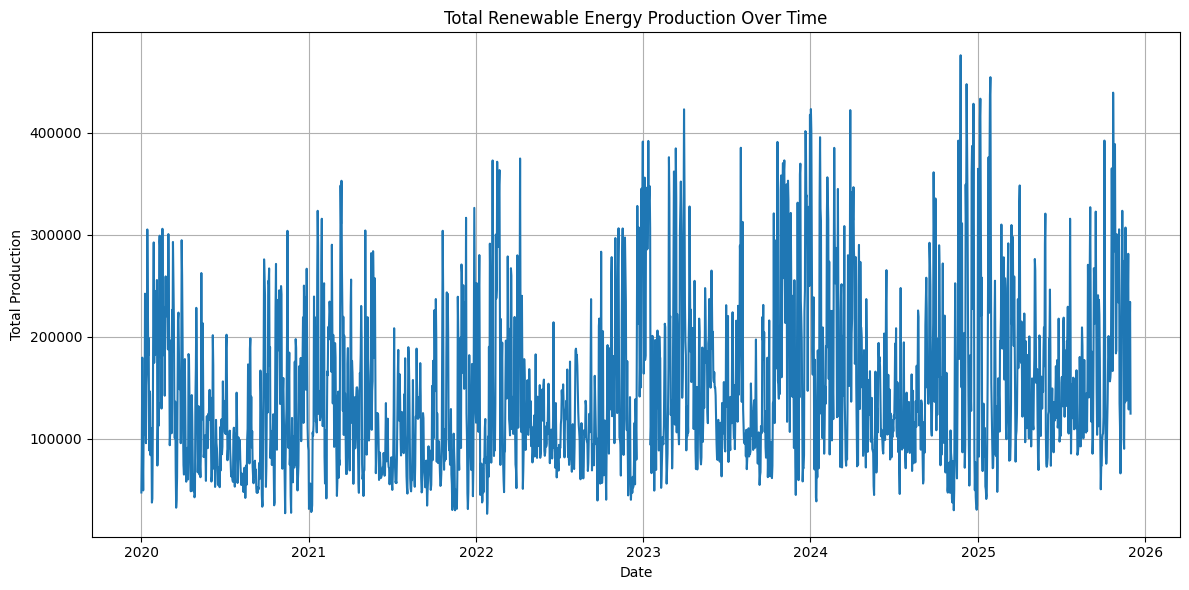

In [6]:
daily_production = (
    df.groupby("Date", as_index=False)["Production"]
      .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(daily_production["Date"], daily_production["Production"])
plt.title("Total Renewable Energy Production Over Time")
plt.xlabel("Date")
plt.ylabel("Total Production")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** This chronological plot shows how total production changes over time. Repeated rises and falls may indicate seasonality, while abrupt peaks or drops should be checked as possible operational events rather than removed automatically.

## 5.2 Average Production by Energy Source

,Average Production
Source,
Wind,"6,308.2626"
Solar,"5,793.8457"
Mixed,"1,737.0000"


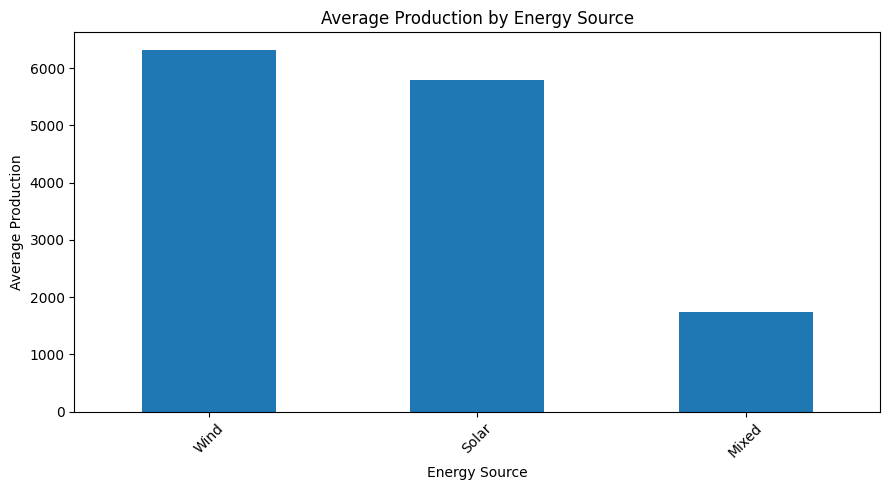

In [7]:
production_by_source = (
    df.groupby("Source")["Production"]
      .mean()
      .sort_values(ascending=False)
)

display(production_by_source.to_frame("Average Production"))

production_by_source.plot(kind="bar", figsize=(9, 5))
plt.title("Average Production by Energy Source")
plt.xlabel("Energy Source")
plt.ylabel("Average Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Average production differs across energy sources, so `Source` is an informative categorical predictor. One-hot encoding is used later because the source names have no natural numerical order.

## 5.3 Monthly Production Pattern

,Average Production
Month_Number,
1,"6,911.2375"
2,"7,792.2238"
3,"7,154.3042"
4,"6,314.3238"
5,"5,805.2567"
6,"4,586.4493"
7,"5,231.2704"
8,"4,905.3804"
9,"5,286.7185"


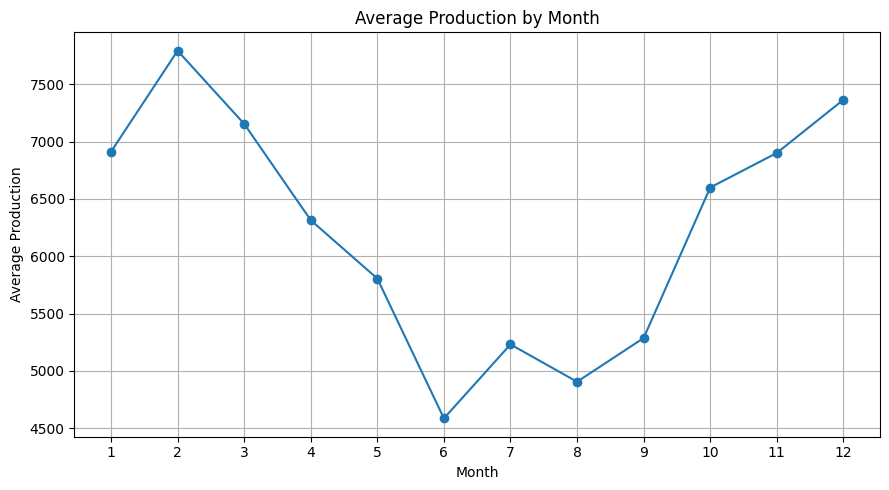

In [8]:
monthly_production = (
    df.assign(Month_Number=df["Date"].dt.month)
      .groupby("Month_Number")["Production"]
      .mean()
)

display(monthly_production.to_frame("Average Production"))

monthly_production.plot(kind="line", marker="o", figsize=(9, 5))
plt.title("Average Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** The monthly pattern indicates whether production has annual seasonality. Because month is cyclical, sine and cosine encodings are added later so December and January remain close in feature space.

## 5.4 Average Production by Start Hour

,Average Production
Start_Hour,
0,"5,313.6969"
1,"5,208.0106"
2,"5,087.7742"
3,"4,972.2119"
4,"4,884.6474"
5,"4,849.2837"
6,"4,869.5627"
7,"5,086.3910"
8,"5,491.7422"


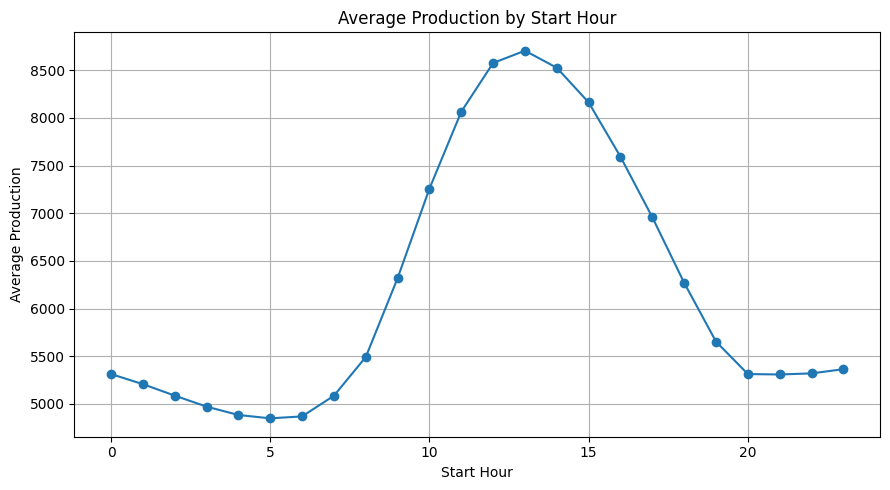

In [9]:
hourly_production = (
    df.groupby("Start_Hour")["Production"]
      .mean()
)

display(hourly_production.to_frame("Average Production"))

hourly_production.plot(kind="line", marker="o", figsize=(9, 5))
plt.title("Average Production by Start Hour")
plt.xlabel("Start Hour")
plt.ylabel("Average Production")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** Hourly variation shows whether production follows a daily operating pattern. `Start_Hour` and `End_Hour` are therefore retained as model inputs.

## 5.5 Outlier Review

<Figure size 1000x500 with 0 Axes>

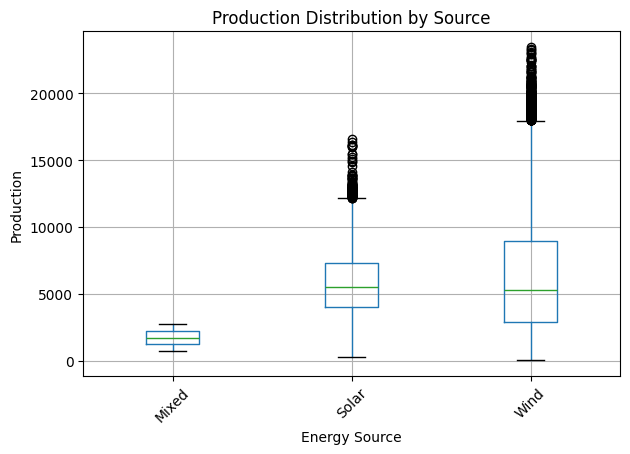

In [10]:
plt.figure(figsize=(10, 5))
df.boxplot(column="Production", by="Source", rot=45)
plt.title("Production Distribution by Source")
plt.suptitle("")
plt.xlabel("Energy Source")
plt.ylabel("Production")
plt.tight_layout()
plt.show()

**Interpretation:** The boxplot highlights extreme values within each source. These points are not removed automatically because they may represent valid high-production periods; they should be investigated using operational or measurement context.

# 6. Time Feature Engineering
Time-derived variables are created once. Cyclical encodings preserve the circular relationship of month and day of week.

In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DayOfWeek_Sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DayOfWeek_Cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

display(
    df[
        [
            "Date", "Year", "Month", "Day", "DayOfWeek", "IsWeekend",
            "Month_Sin", "Month_Cos", "DayOfWeek_Sin", "DayOfWeek_Cos"
        ]
    ].head()
)

,Date,Year,Month,Day,DayOfWeek,IsWeekend,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,2020-04-08,2020,4,8,2,0,0.8660,-0.5000,0.9749,-0.2225
1,2022-06-15,2022,6,15,2,0,0.0000,-1.0000,0.9749,-0.2225
2,2020-01-01,2020,1,1,2,0,0.5000,0.8660,0.9749,-0.2225
3,2020-01-01,2020,1,1,2,0,0.5000,0.8660,0.9749,-0.2225
4,2020-01-01,2020,1,1,2,0,0.5000,0.8660,0.9749,-0.2225


# 7. Lag and Rolling Features
Lag features are created separately within each energy source. The rolling mean uses `shift(1)` before `rolling(3)`, preventing the current target value from leaking into its own predictor.

In [12]:
df["Lag_1"] = df.groupby("Source")["Production"].shift(1)
df["Lag_2"] = df.groupby("Source")["Production"].shift(2)

df["Rolling_Mean_3"] = (
    df.groupby("Source")["Production"]
      .transform(lambda values: values.shift(1).rolling(3).mean())
)

required_history = ["Lag_1", "Lag_2", "Rolling_Mean_3"]
rows_before_history_filter = len(df)

df = df.dropna(subset=required_history).reset_index(drop=True)

print(
    "Rows removed because sufficient source-specific history was unavailable:",
    rows_before_history_filter - len(df)
)
display(df[["Source", "Date", "Production", "Lag_1", "Lag_2", "Rolling_Mean_3"]].head())

Rows removed because sufficient source-specific history was unavailable: 8


,Source,Date,Production,Lag_1,Lag_2,Rolling_Mean_3
0,Solar,2020-01-05,3282,"1,783.0000","2,179.0000","2,168.6667"
1,Solar,2020-01-05,3338,"3,282.0000","1,783.0000","2,414.6667"
2,Solar,2020-01-05,3227,"3,338.0000","3,282.0000","2,801.0000"
3,Solar,2020-01-05,2952,"3,227.0000","3,338.0000","3,282.3333"
4,Solar,2020-01-05,2299,"2,952.0000","3,227.0000","3,172.3333"


# 8. Define Features and Target
Categorical features remain readable strings. Redundant text columns such as `Month_Name` and `Day_Name` are excluded because equivalent numerical and cyclical features are already available.

In [13]:
feature_columns = [
    "Start_Hour",
    "End_Hour",
    "Source",
    "Season",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos",
    "Lag_1",
    "Lag_2",
    "Rolling_Mean_3",
]

X = df[feature_columns].copy()
y = df["Production"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Features shape: (51856, 16)
Target shape: (51856,)


,Start_Hour,End_Hour,Source,Season,Year,Month,Day,DayOfWeek,IsWeekend,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Lag_1,Lag_2,Rolling_Mean_3
0,11,12,Solar,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"1,783.0000","2,179.0000","2,168.6667"
1,12,13,Solar,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"3,282.0000","1,783.0000","2,414.6667"
2,13,14,Solar,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"3,338.0000","3,282.0000","2,801.0000"
3,14,15,Solar,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"3,227.0000","3,338.0000","3,282.3333"
4,15,16,Solar,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"2,952.0000","3,227.0000","3,172.3333"


# 9. Chronological Train-Test Split
The first 80% of observations are used for training and the latest 20% for testing. No random split or shuffling is used in the final forecasting evaluation.

In [14]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

test_dates = df["Date"].iloc[split_index:].copy()
test_sources = df["Source"].iloc[split_index:].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining period:")
print(df["Date"].iloc[:split_index].min(), "to", df["Date"].iloc[:split_index].max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

Training rows: 41484
Testing rows: 10372

Training period:
2020-01-01 00:00:00 to 2025-11-26 00:00:00

Testing period:
2024-05-26 00:00:00 to 2025-11-30 00:00:00


# 10. Preprocessing Pipeline
Numerical and categorical columns use separate preprocessing steps. All preprocessing is fitted only through the model pipeline on training folds, preventing leakage.

In [15]:
numerical_features = [
    "Start_Hour",
    "End_Hour",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos",
    "Lag_1",
    "Lag_2",
    "Rolling_Mean_3",
]

categorical_features = [
    "Source",
    "Season",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 14
Categorical features: 2


# 11. Naive Persistence Baseline
The persistence baseline predicts that the next production value will equal the previous value from the same source (`Lag_1`). A useful forecasting model should outperform this simple benchmark.

In [16]:
naive_predictions = X_test["Lag_1"]

naive_mae = mean_absolute_error(y_test, naive_predictions)
naive_rmse = mean_squared_error(y_test, naive_predictions) ** 0.5
naive_r2 = r2_score(y_test, naive_predictions)

naive_results = pd.DataFrame([{
    "Model": "Naive Persistence",
    "MAE": naive_mae,
    "RMSE": naive_rmse,
    "R2": naive_r2,
}])

display(naive_results)

,Model,MAE,RMSE,R2
0,Naive Persistence,623.5645,"1,031.4827",0.9492


# 12. Model Creation
Three regression pipelines are compared using identical preprocessing.

In [17]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
        ),
    ),
])

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

models = {
    "Linear Regression": linear_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline,
}

print("Models:", list(models))

Models: ['Linear Regression', 'Decision Tree', 'Random Forest']


# 13. Time-Series Cross-Validation
`TimeSeriesSplit` preserves order inside each validation fold. Lower MAE and RMSE indicate smaller forecast errors, while a lower RMSE standard deviation indicates more stable performance across time periods.

In [18]:
time_series_cv = TimeSeriesSplit(n_splits=5)
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=time_series_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )

    fold_mae = -scores["test_mae"]
    fold_rmse = np.sqrt(-scores["test_mse"])
    fold_r2 = scores["test_r2"]

    cv_results.append({
        "Model": model_name,
        "Mean CV MAE": fold_mae.mean(),
        "Mean CV RMSE": fold_rmse.mean(),
        "Mean CV R2": fold_r2.mean(),
        "RMSE Std": fold_rmse.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("Mean CV RMSE")
      .reset_index(drop=True)
)

display(cv_results_df)

best_cv_row = cv_results_df.iloc[0]
most_stable_row = cv_results_df.sort_values("RMSE Std").iloc[0]

print("Lowest mean CV RMSE:", best_cv_row["Model"])
print("Lowest RMSE standard deviation:", most_stable_row["Model"])
print(
    "Time-series cross-validation is more realistic than random folds because "
    "each validation fold occurs after its corresponding training observations."
)

,Model,Mean CV MAE,Mean CV RMSE,Mean CV R2,RMSE Std
0,Linear Regression,608.0036,868.2008,0.9388,254.9897
1,Random Forest,593.2490,"1,012.9387",0.8712,690.5131
2,Decision Tree,709.2265,"1,240.0305",0.8438,640.2277


Lowest mean CV RMSE: Linear Regression
Lowest RMSE standard deviation: Linear Regression
Time-series cross-validation is more realistic than random folds because each validation fold occurs after its corresponding training observations.


# 14. Test Evaluation and Model Comparison
Every model is fitted on the same chronological training period and evaluated on the same untouched future test period.

In [19]:
test_results = []
test_predictions_by_model = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    test_predictions_by_model[model_name] = predictions

    test_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
    })

test_results_df = (
    pd.DataFrame(test_results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

comparison_results_df = pd.concat(
    [naive_results, test_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(comparison_results_df)

best_model_name = test_results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

best_test_row = test_results_df.iloc[0]

print("Best baseline ML model:", best_model_name)
print(
    "Does the best baseline ML model beat the naive baseline?",
    bool(best_test_row["RMSE"] < naive_rmse),
)

,Model,MAE,RMSE,R2
0,Random Forest,473.5226,855.5474,0.9650
1,Decision Tree,554.3268,951.9194,0.9567
2,Linear Regression,585.8732,977.9550,0.9543
3,Naive Persistence,623.5645,"1,031.4827",0.9492


Best baseline ML model: Random Forest
Does the best baseline ML model beat the naive baseline? True


# 15. Chronological Actual-versus-Predicted Plot
Predictions are plotted against real dates, not shuffled row numbers.

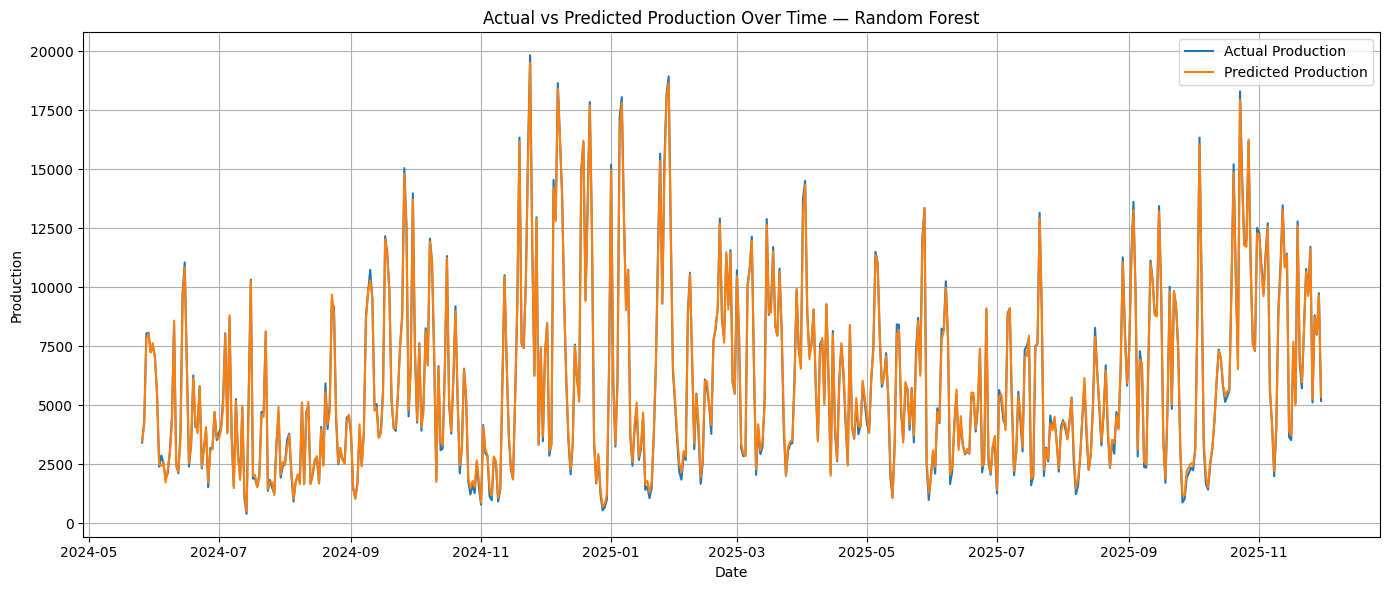

In [20]:
comparison_df = pd.DataFrame({
    "Date": test_dates.values,
    "Source": test_sources.values,
    "Actual Production": y_test.values,
    "Predicted Production": best_predictions,
})

comparison_df = comparison_df.sort_values(["Date", "Source"])

daily_comparison = (
    comparison_df.groupby("Date", as_index=False)
                 .mean(numeric_only=True)
)

plt.figure(figsize=(14, 6))
plt.plot(
    daily_comparison["Date"],
    daily_comparison["Actual Production"],
    label="Actual Production",
)
plt.plot(
    daily_comparison["Date"],
    daily_comparison["Predicted Production"],
    label="Predicted Production",
)
plt.title(f"Actual vs Predicted Production Over Time — {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** The two chronological lines show how closely the selected model follows future production patterns. Persistent gaps indicate systematic bias, while isolated gaps indicate specific periods with unusually large forecast errors.

# 16. Residual Analysis
Residuals are calculated as `actual − predicted`. A reliable model should have residuals distributed around zero without a strong visible pattern.

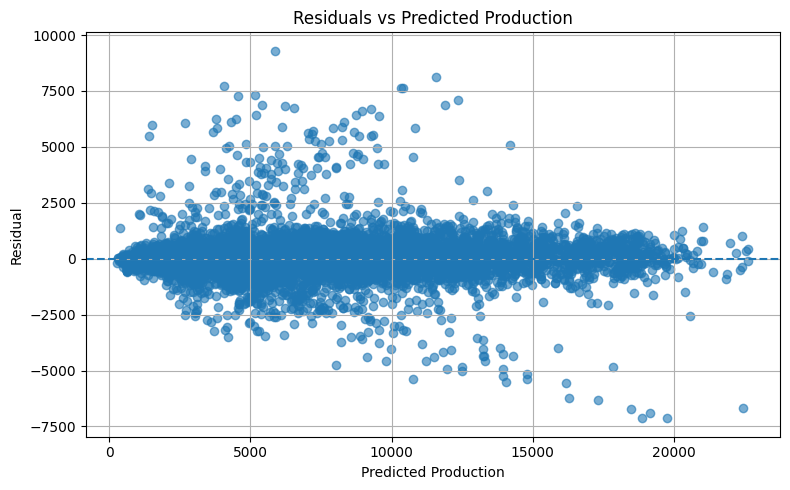

In [21]:
residuals = y_test.values - best_predictions

plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Production")
plt.xlabel("Predicted Production")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

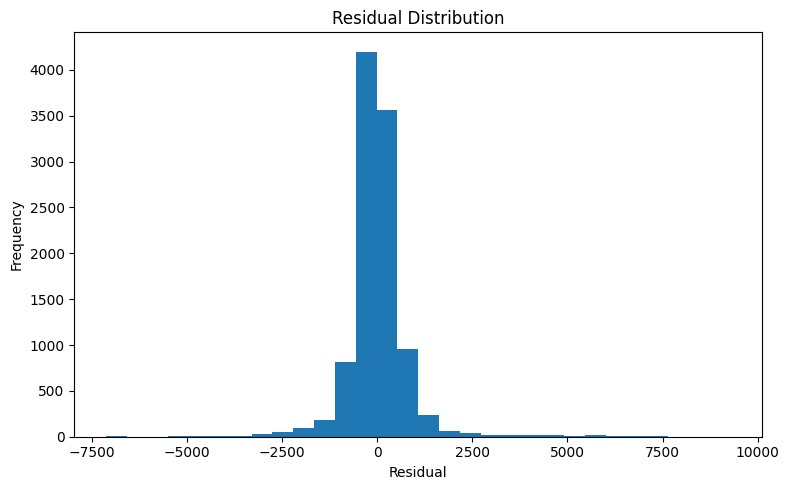

,Residual
count,"10,372.0000"
mean,9.8828
std,855.5315
min,"-7,138.4283"
25%,-283.8694
50%,-35.9948
75%,260.9864
max,"9,298.9705"


Mean residual: 9.882772524448121
Median residual: -35.99477329444733
Overall mean absolute residual: 473.5226451142797
Mean absolute residual in highest 10% of predictions: 587.0970719996459
Residuals are approximately centered around zero.
Errors increase at high predicted production values.
Review the scatter plot for curves, funnels, or clusters. These patterns can reveal non-linearity, changing error variance, or source-specific behavior.


In [22]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

residual_summary = pd.Series(residuals).describe()
display(residual_summary.to_frame("Residual"))

high_prediction_threshold = np.quantile(best_predictions, 0.90)
high_error_mae = np.mean(
    np.abs(residuals[best_predictions >= high_prediction_threshold])
)
overall_error_mae = np.mean(np.abs(residuals))

print("Mean residual:", residuals.mean())
print("Median residual:", np.median(residuals))
print("Overall mean absolute residual:", overall_error_mae)
print("Mean absolute residual in highest 10% of predictions:", high_error_mae)

if abs(residuals.mean()) <= 0.05 * np.std(residuals):
    print("Residuals are approximately centered around zero.")
else:
    print("Residuals show a noticeable average bias away from zero.")

if high_error_mae > overall_error_mae:
    print("Errors increase at high predicted production values.")
else:
    print("Errors do not clearly increase at high predicted production values.")

print(
    "Review the scatter plot for curves, funnels, or clusters. "
    "These patterns can reveal non-linearity, changing error variance, or source-specific behavior."
)

# 17. Overfitting Check
Training and testing RMSE are compared for the selected baseline model.

In [23]:
train_predictions = best_model.predict(X_train)
test_predictions = best_model.predict(X_test)

train_rmse = mean_squared_error(y_train, train_predictions) ** 0.5
test_rmse = mean_squared_error(y_test, test_predictions) ** 0.5
rmse_difference = test_rmse - train_rmse

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)
print("RMSE Difference:", rmse_difference)

if test_rmse <= train_rmse * 1.15:
    print("Interpretation: Training and testing errors are reasonably similar.")
elif train_rmse < test_rmse:
    print("Interpretation: The lower training error suggests possible overfitting.")
else:
    print("Interpretation: Review the split and data distribution because test error is unexpectedly lower.")

Training RMSE: 455.1847044549153
Testing RMSE: 855.5473646504497
RMSE Difference: 400.36266019553443
Interpretation: The lower training error suggests possible overfitting.


# 18. Hyperparameter Tuning
Random Forest is tuned only after clean baselines and time-series cross-validation have been established. The full parameter grid follows the feedback plan exactly.

> This grid evaluates 162 parameter combinations across 5 time-series folds and may take several minutes.

In [24]:
parameter_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [8, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8],
}

grid_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=parameter_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best CV RMSE:
993.8563563345908


In [25]:
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = mean_squared_error(y_test, tuned_predictions) ** 0.5
tuned_r2 = r2_score(y_test, tuned_predictions)

tuned_results = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "MAE": tuned_mae,
    "RMSE": tuned_rmse,
    "R2": tuned_r2,
}])

final_comparison_df = pd.concat(
    [naive_results, test_results_df, tuned_results],
    ignore_index=True,
).sort_values("RMSE").reset_index(drop=True)

display(final_comparison_df)

print("Tuned model beats naive baseline:", tuned_rmse < naive_rmse)
print(
    "Tuned model improves over baseline Random Forest:",
    tuned_rmse
    < test_results_df.loc[
        test_results_df["Model"] == "Random Forest", "RMSE"
      ].iloc[0],
)

,Model,MAE,RMSE,R2
0,Tuned Random Forest,455.3477,836.7629,0.9666
1,Random Forest,473.5226,855.5474,0.9650
2,Decision Tree,554.3268,951.9194,0.9567
3,Linear Regression,585.8732,977.9550,0.9543
4,Naive Persistence,623.5645,"1,031.4827",0.9492


Tuned model beats naive baseline: True
Tuned model improves over baseline Random Forest: True


# 19. Feature Importance
Feature names are extracted from the complete tuned pipeline. The top features are displayed and interpreted rather than merely plotted.

,Feature,Importance
0,numeric__Lag_1,0.7935
1,numeric__Rolling_Mean_3,0.1376
2,numeric__Lag_2,0.0402
3,numeric__End_Hour,0.0087
4,numeric__Start_Hour,0.0065
5,numeric__Year,0.0020
6,categorical__Source_Solar,0.0020
7,categorical__Source_Wind,0.0020
8,numeric__Day,0.0017
9,numeric__Month_Cos,0.0015


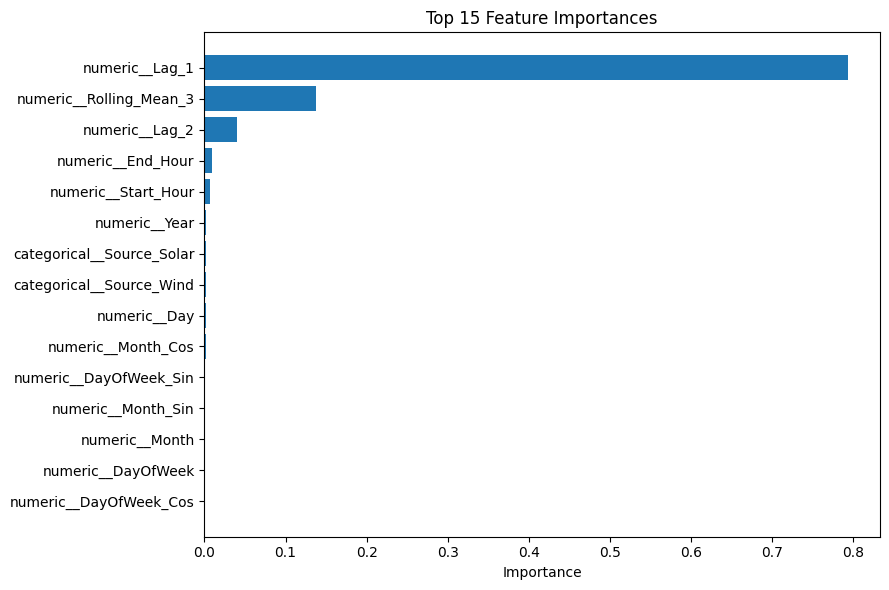

In [26]:
final_model = tuned_model

feature_names = (
    final_model.named_steps["preprocessor"]
               .get_feature_names_out()
)

feature_importances = (
    final_model.named_steps["model"]
               .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importances,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15))

top_features = importance_df.head(15)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [27]:
def feature_group_importance(prefix_or_name):
    mask = importance_df["Feature"].str.contains(prefix_or_name, regex=False)
    return importance_df.loc[mask, "Importance"].sum()

lag_1_importance = feature_group_importance("Lag_1")
source_importance = feature_group_importance("Source")
season_importance = feature_group_importance("Season")
hour_importance = (
    feature_group_importance("Start_Hour")
    + feature_group_importance("End_Hour")
)

print("Lag_1 total importance:", lag_1_importance)
print("Source-related total importance:", source_importance)
print("Season-related total importance:", season_importance)
print("Hour-related total importance:", hour_importance)

print("\nMost important feature:", importance_df.iloc[0]["Feature"])
print(
    "Features with near-zero importance:",
    importance_df.loc[importance_df["Importance"] < 0.001, "Feature"].tolist(),
)

Lag_1 total importance: 0.7935214996583513
Source-related total importance: 0.003980997849345512
Season-related total importance: 0.0007913189391218866
Hour-related total importance: 0.015258881937648034

Most important feature: numeric__Lag_1
Features with near-zero importance: ['numeric__DayOfWeek_Sin', 'numeric__Month_Sin', 'numeric__Month', 'numeric__DayOfWeek', 'numeric__DayOfWeek_Cos', 'categorical__Season_Summer', 'categorical__Season_Spring', 'categorical__Season_Winter', 'numeric__IsWeekend', 'categorical__Season_Fall']


**Interpretation:** Lag and rolling variables represent recent source-specific production history and are expected to be strong predictors. The one-hot source features measure differences among renewable technologies, while seasonal and hourly variables capture recurring calendar and operating patterns. Features with nearly zero importance may add little predictive value and can be reviewed in future feature-selection experiments.

# 20. Save Final Pipeline
The complete tuned pipeline is saved, keeping preprocessing and the Random Forest estimator together.

In [28]:
model_output_path = "renewable_energy_forecasting_pipeline.joblib"

joblib.dump(tuned_model, model_output_path)
print("Saved pipeline to:", model_output_path)

loaded_model = joblib.load(model_output_path)
loaded_predictions = loaded_model.predict(X_test.head(5))

print("Loaded-model predictions:")
print(loaded_predictions)

assert np.allclose(
    loaded_predictions,
    tuned_model.predict(X_test.head(5)),
)
print("Reload verification passed.")

Saved pipeline to: renewable_energy_forecasting_pipeline.joblib
Loaded-model predictions:
[4370.23584524 3550.34748437 3217.99095551 3090.41316065 2955.00558069]
Reload verification passed.


# 21. Final Conclusion and Limitations
The following cell generates a conclusion using the actual results from this run.

In [29]:
best_cv_model_name = cv_results_df.iloc[0]["Model"]
best_cv_rmse = cv_results_df.iloc[0]["Mean CV RMSE"]

tuned_train_predictions = tuned_model.predict(X_train)
tuned_train_rmse = mean_squared_error(
    y_train,
    tuned_train_predictions,
) ** 0.5

tuned_rmse_gap = tuned_rmse - tuned_train_rmse
top_three_features = importance_df.head(3)["Feature"].tolist()

beats_naive_text = "does" if tuned_rmse < naive_rmse else "does not"
overfit_text = (
    "shows a potentially meaningful train-test gap"
    if tuned_rmse > tuned_train_rmse * 1.15
    else "shows a reasonably controlled train-test gap"
)

conclusion = f'''
The tuned Random Forest was evaluated on a chronological future holdout period.
The naive persistence baseline achieved an RMSE of {naive_rmse:,.2f}.
The strongest baseline model in time-series cross-validation was
{best_cv_model_name}, with a mean CV RMSE of {best_cv_rmse:,.2f}.

On the untouched test period, the tuned Random Forest achieved:
- MAE: {tuned_mae:,.2f}
- RMSE: {tuned_rmse:,.2f}
- R²: {tuned_r2:.4f}

The tuned model {beats_naive_text} outperform the naive persistence forecast.
Its training RMSE was {tuned_train_rmse:,.2f}, and its test RMSE was
{tuned_rmse:,.2f}; therefore, it {overfit_text}.

The three most important transformed features were:
{", ".join(top_three_features)}.

Limitations:
1. This is a short-horizon supervised forecasting experiment based mainly on
   historical production and calendar variables.
2. Weather variables, maintenance events, demand constraints, and equipment
   availability are not included.
3. The chronological holdout provides one future-period test; additional
   walk-forward evaluation would strengthen the evidence.
4. Separate models for each energy source and longer lag windows may improve
   source-specific forecasts.
'''

print(conclusion)


The tuned Random Forest was evaluated on a chronological future holdout period.
The naive persistence baseline achieved an RMSE of 1,031.48.
The strongest baseline model in time-series cross-validation was
Linear Regression, with a mean CV RMSE of 868.20.

On the untouched test period, the tuned Random Forest achieved:
- MAE: 455.35
- RMSE: 836.76
- R²: 0.9666

The tuned model does outperform the naive persistence forecast.
Its training RMSE was 338.93, and its test RMSE was
836.76; therefore, it shows a potentially meaningful train-test gap.

The three most important transformed features were:
numeric__Lag_1, numeric__Rolling_Mean_3, numeric__Lag_2.

Limitations:
1. This is a short-horizon supervised forecasting experiment based mainly on
   historical production and calendar variables.
2. Weather variables, maintenance events, demand constraints, and equipment
   availability are not included.
3. The chronological holdout provides one future-period test; additional
   walk-forward e